In [2]:
import pandas as pd

data_path = "/content/email_support_only (1).csv"
df = pd.read_csv(data_path)

df.head(1)


,subject,body,answer,type,queue,priority,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN


In [3]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["text"] = df["body"].apply(clean_text)


In [4]:
df["text"] = (
    df["subject"].fillna("") + " " +
    df["body"].fillna("")
).apply(clean_text)


In [5]:
from sklearn.preprocessing import LabelEncoder

queue_le = LabelEncoder()
priority_map = {"Low": 0, "Medium": 1, "High": 2}

df["queue_enc"] = queue_le.fit_transform(df["queue"])
df["priority_enc"] = df["priority"].map(priority_map)


In [6]:
queue_mapping = pd.DataFrame({
    "queue_label": queue_le.classes_,
    "encoded_value": range(len(queue_le.classes_))
})

queue_mapping


,queue_label,encoded_value
0,Billing and Payments,0
1,Customer Service,1
2,General Inquiry,2
3,Human Resources,3
4,IT Support,4
5,Product Support,5
6,Returns and Exchanges,6
7,Sales and Pre-Sales,7
8,Service Outages and Maintenance,8
9,Technical Support,9


In [7]:
tag_cols = [f"tag_{i}" for i in range(1, 9)]

df["tags"] = df[tag_cols].values.tolist()
df["tags"] = df["tags"].apply(
    lambda x: [t for t in x if pd.notna(t)]
)


In [8]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
X_tags = mlb.fit_transform(df["tags"])

In [9]:
type_le = LabelEncoder()
y = type_le.fit_transform(df["type"])

In [10]:
from sklearn.model_selection import train_test_split

X_text_tr, X_text_te, \
X_queue_tr, X_queue_te, \
X_priority_tr, X_priority_te, \
X_tags_tr, X_tags_te, \
y_tr, y_te = train_test_split(
    df["text"].values,
    df["queue_enc"].values,
    df["priority_enc"].values,
    X_tags,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 30000
MAX_LEN = 250

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_text_tr)

X_text_tr_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_text_tr),
    maxlen=MAX_LEN
)

X_text_te_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_text_te),
    maxlen=MAX_LEN
)

In [12]:
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, MaxPooling1D,
    LSTM, Dense, Dropout, Concatenate, Flatten
)
from tensorflow.keras.models import Model


In [13]:
text_in = Input(shape=(MAX_LEN,), name="text_input")
x = Embedding(MAX_WORDS, 128)(text_in)
x = Conv1D(128, 5, activation="relu")(x)
x = MaxPooling1D(2)(x)
x = LSTM(64)(x)


queue_in = Input(shape=(1,), name="queue_input")
q = Embedding(len(queue_le.classes_), 8)(queue_in)
q = Flatten()(q)
q = Dense(8, activation="relu")(q)


priority_in = Input(shape=(1,), name="priority_input")
p = Embedding(df["priority_enc"].nunique(), 4)(priority_in)
p = Flatten()(p)
p = Dense(4, activation="relu")(p)


tags_in = Input(shape=(X_tags.shape[1],), name="tags_input")
t = Dense(32, activation="relu")(tags_in)


combined = Concatenate()([x, q, p, t])
combined = Dense(64, activation="relu")(combined)
combined = Dropout(0.5)(combined)

output = Dense(len(type_le.classes_), activation="softmax")(combined)

model = Model(
    inputs=[text_in, queue_in, priority_in, tags_in],
    outputs=output
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 250, 128)  │  3,840,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ queue_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ priority_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 246, 128)  │     82,048 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 8)      │         80 │ queue_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 4)      │          0 │ priority_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 123, 128)  │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 4)         │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tags_input          │ (None, 886)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     49,408 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │         72 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │         20 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │     28,384 │ tags_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 108)       │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ dense[0][0],      │
│                     │                   │            │ dense_1[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      6,976 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 4)         │        260 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 4,007,248 (15.29 MB)

 Trainable params: 4,007,248 (15.29 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_tr),
    y=y_tr
)

class_weights = dict(zip(np.unique(y_tr), class_weights))

print("Class weights:", class_weights)


Class weights: {np.int64(0): np.float64(2.3955278592375366), np.int64(1): np.float64(0.6215522160928286), np.int64(2): np.float64(1.2026131762973868), np.int64(3): np.float64(0.8755359056806002)}


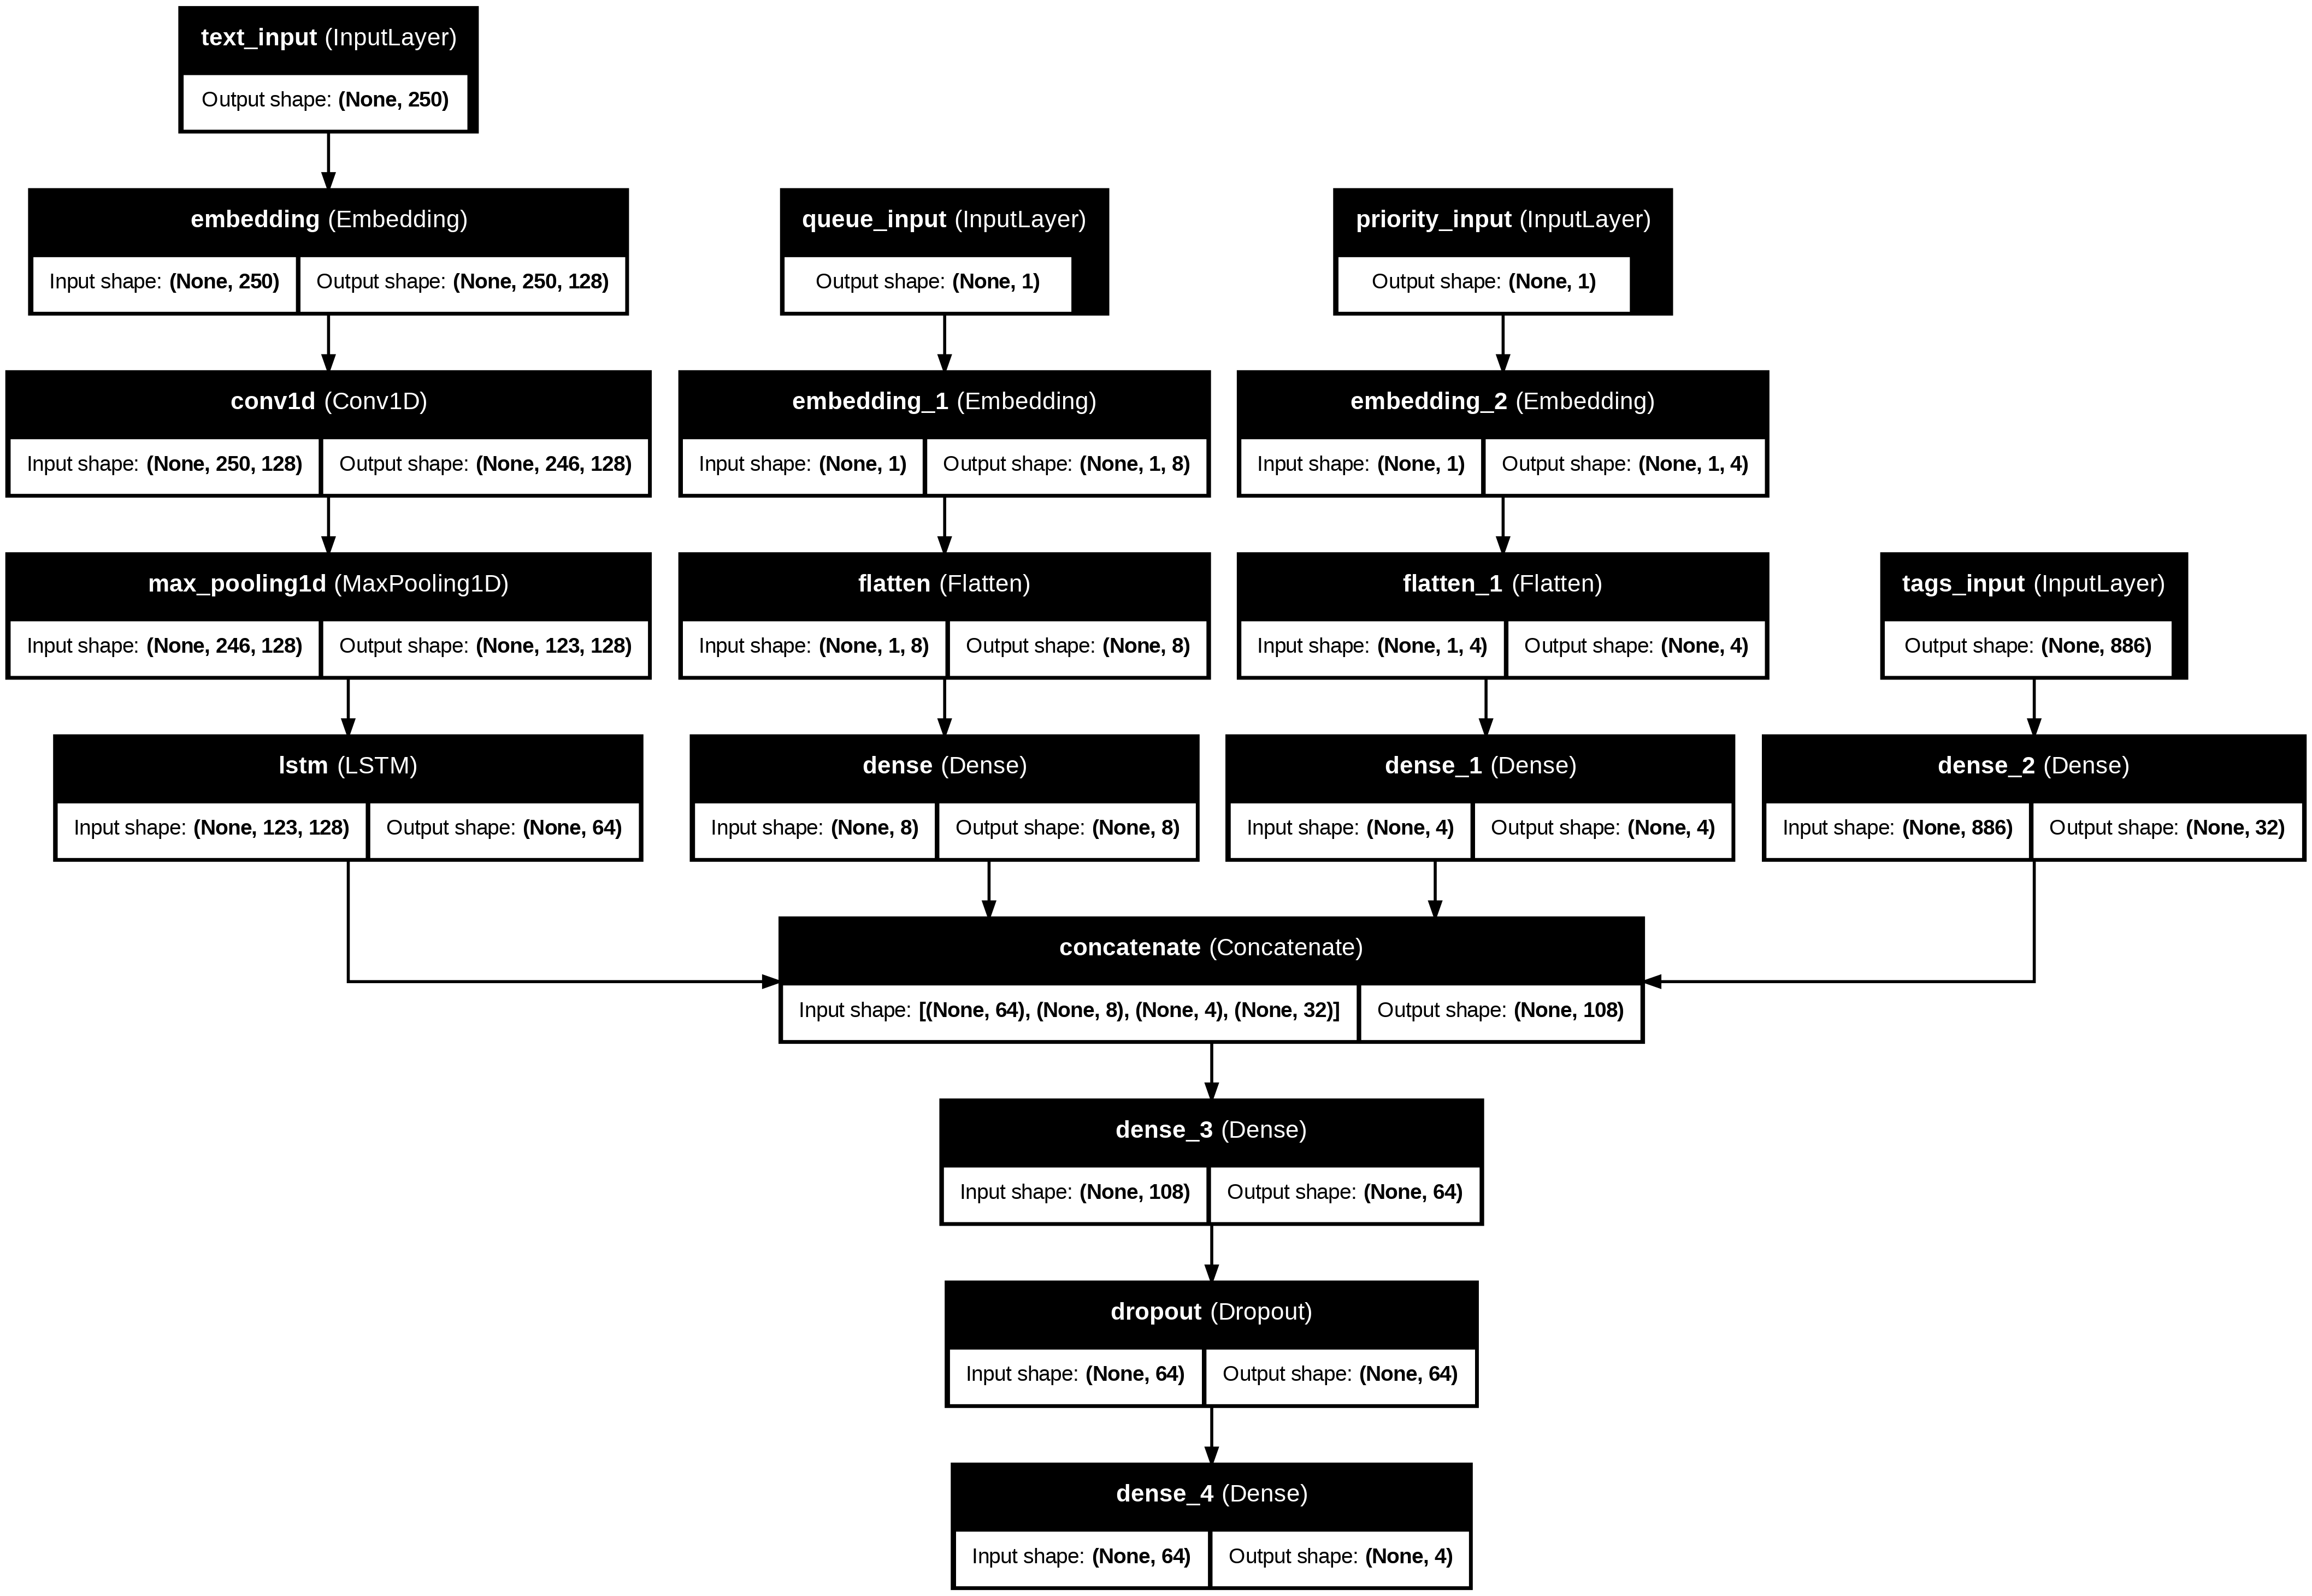

In [15]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="model_graph.png",
    show_shapes=True,
    show_layer_names=True
)

In [16]:
history = model.fit(
    [X_text_tr_pad, X_queue_tr, X_priority_tr, X_tags_tr],
    y_tr,
    validation_data=(
        [X_text_te_pad, X_queue_te, X_priority_te, X_tags_te],
        y_te
    ),
    epochs=15,
    batch_size=32,
    class_weight=class_weights
)


Epoch 1/15
409/409 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.5731 - loss: 0.8558 - val_accuracy: 0.6524 - val_loss: 0.4687
Epoch 2/15
409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7080 - loss: 0.4128 - val_accuracy: 0.7408 - val_loss: 0.4350
Epoch 3/15
409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7495 - loss: 0.3744 - val_accuracy: 0.6753 - val_loss: 0.4734
Epoch 4/15
409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7605 - loss: 0.3487 - val_accuracy: 0.7222 - val_loss: 0.4384
Epoch 5/15
409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8074 - loss: 0.3180 - val_accuracy: 0.7111 - val_loss: 0.4398
Epoch 6/15
409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8365 - loss: 0.2852 - val_accuracy: 0.8293 - val_loss: 0.3630
Epoch 7/15
409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8829 - loss: 0.2278 - val_accuracy: 0.7818 - val_loss: 0.4201
Epoch 8/15
409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9251 - loss: 0.1629 - val_acc

In [17]:
from sklearn.metrics import classification_report


y_pred_probs = model.predict(
    [X_text_te_pad, X_queue_te, X_priority_te, X_tags_te]
)

y_pred = y_pred_probs.argmax(axis=1)

print("Classification Report:\n")
print(
    classification_report(
        y_te,
        y_pred,
        target_names=type_le.classes_
    )
)


103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Classification Report:

              precision    recall  f1-score   support

      Change       0.98      0.97      0.97       341
    Incident       0.86      0.74      0.80      1314
     Problem       0.61      0.77      0.68       680
     Request       0.98      1.00      0.99       933

    accuracy                           0.84      3268
   macro avg       0.86      0.87      0.86      3268
weighted avg       0.86      0.84      0.85      3268



In [18]:
!pip install gradio


In [19]:
import gradio as gr
import random

def gradio_predict(subject, body, queue, priority, tags):

    text = clean_text(subject + " " + body)
    text_pad = pad_sequences(
        tokenizer.texts_to_sequences([text]),
        maxlen=MAX_LEN
    )

    q_enc = queue_le.transform([queue])
    p_enc = priority_map[priority]
    tags_list = [t.strip() for t in tags.split(",") if t.strip()]
    tags_enc = mlb.transform([tags_list])


    probs = model.predict(
        [text_pad, q_enc, np.array([p_enc]), tags_enc],
        verbose=0
    )[0]

    label = probs.argmax()
    confidence = probs[label]
    predicted_type = type_le.inverse_transform([label])[0]

    pool = df[ (df["type"] == predicted_type) &  (df["queue"] == queue) ]["answer"].dropna().tolist()

    reply = random.choice(pool) if pool else "Thank you for reaching out. Our team will get back to you."

    return (
        f"Predicted Ticket Type: {predicted_type}",
        f"Confidence: {confidence:.2f}",
        reply
    )


with gr.Blocks(title="Customer Support Email Classifier") as demo:

    gr.Markdown(
        """
        # ✉️ Customer Support Email Classification System
        Automatically classify customer emails and generate response suggestions using a deep learning NLP model.
        """
    )

    with gr.Row():
        subject = gr.Textbox(label="Subject", placeholder="Enter email subject")
        queue = gr.Dropdown(
            choices=list(queue_le.classes_),
            label="Queue"
        )

    with gr.Row():
        priority = gr.Dropdown(
            choices=list(priority_map.keys()),
            label="Priority"
        )
        tags = gr.Textbox(
            label="Tags",
            placeholder="comma separated tags (optional)"
        )

    body = gr.Textbox(
        label="Email Body",
        placeholder="Enter email body",
        lines=6
    )

    submit = gr.Button("Predict & Generate Reply")

    output_type = gr.Textbox(label="Ticket Type")
    output_conf = gr.Textbox(label="Confidence")
    output_reply = gr.Textbox(label="Suggested Reply", lines=4)

    submit.click(
        gradio_predict,
        inputs=[subject, body, queue, priority, tags],
        outputs=[output_type, output_conf, output_reply]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1206b114fc86f3081f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
